# 04 · Hipóteses para Apresentação — Projeto Vértice (Vértice Retail)

**Objetivo deste notebook:** reunir, num único lugar, **apenas as hipóteses com
suporte estatístico real** (confirmadas ou refutadas com evidência robusta —
testadas e checadas quanto à robustez nos notebooks 02 e 03), cada uma com o
**gráfico certo para mostrar à diretoria** e o **teste que a sustenta**. É o
material-fonte para os slides "Árvore de hipóteses" e "Principais insights" da
Apresentação Final (roteiro do case, seção 8).

Este notebook não reintroduz nenhuma análise nova — cada gráfico e teste aqui é uma
versão **redesenhada para apresentação** (forma de gráfico mais direta, paleta
fixa, um único eixo, rótulos diretos no lugar de legendas genéricas) do que já foi
explorado no notebook 02 e testado no notebook 03. Para o detalhamento completo
(premissas, checagens de robustez, achados descartados em detalhe), ver os
notebooks 01–03.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from scipy import stats

%matplotlib inline
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

ALPHA = 0.05

# --- Paleta fixa (ordem categórica nunca é ciclada; cores atribuídas pela FUNÇÃO
#     que exercem — identidade, sequência ou destaque — nunca por preferência) ---
INK_PRIMARY   = '#0b0b0b'
INK_SECONDARY = '#52514e'
MUTED         = '#898781'
GRID          = '#e1e0d9'
BASELINE      = '#c3c2b7'
DEGRAY        = '#c9c8c2'   # cinza de desênfase (forma "emphasis": 1 destaque + resto cinza)

CAT = {  # paleta categórica, ordem fixa
    'blue': '#2a78d6', 'orange': '#eb6834', 'aqua': '#1baf7a', 'yellow': '#eda100',
    'magenta': '#e87ba4', 'green': '#008300', 'violet': '#4a3aa7', 'red': '#e34948',
}
STATUS = {'good': '#0ca30c', 'warning': '#fab219', 'serious': '#ec835a', 'critical': '#d03b3b'}
SEQ_BLUE = ['#cde2fb', '#9ec5f4', '#6da7ec', '#3987e5', '#256abf', '#184f95', '#0d366b']  # claro -> escuro

plt.rcParams.update({
    'font.family': ['Segoe UI', 'DejaVu Sans', 'sans-serif'],
    'axes.edgecolor': BASELINE, 'axes.labelcolor': INK_SECONDARY,
    'text.color': INK_PRIMARY, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': False, 'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
})


def clean_ax(ax, hide_spines=('top', 'right', 'left')):
    for s in hide_spines:
        ax.spines[s].set_visible(False)
    for s in ax.spines:
        if s not in hide_spines:
            ax.spines[s].set_color(BASELINE)
            ax.spines[s].set_linewidth(0.8)


def hbar_emphasis(ax, labels, values, highlight, highlight_color, value_fmt='{:.1%}', title=None):
    '''Barra horizontal: 1 categoria em destaque (highlight_color), resto em cinza.
    Forma "emphasis" — usar quando 1 série é o ponto e as demais são contexto.'''
    order = np.argsort(values)
    labels_o = [labels[i] for i in order]
    values_o = [values[i] for i in order]
    colors = [highlight_color if l == highlight else DEGRAY for l in labels_o]
    bars = ax.barh(labels_o, values_o, color=colors, height=0.62)
    for b, v in zip(bars, values_o):
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2, '  ' + value_fmt.format(v),
                va='center', ha='left', fontsize=10, color=INK_PRIMARY)
    ax.set_xlim(0, max(values) * 1.22)
    ax.xaxis.set_visible(False)
    clean_ax(ax)
    if title:
        ax.set_title(title, fontsize=12, color=INK_PRIMARY, loc='left', pad=10)
    return ax


def hbar_sequential(ax, labels, values, value_fmt='{:.1%}', title=None, ramp=SEQ_BLUE, sort_by_value=True):
    '''Barra horizontal, rampa sequencial 1 matiz (claro->escuro).
    sort_by_value=True: ordena e colore pela MAGNITUDE plotada (uso padrão — "comparar
    magnitude, baixo -> alto", ex.: ranking de LTV por segmento).
    sort_by_value=False: preserva a ordem de entrada e colore por ELA (uso para eixos
    ordinais onde a cor deve seguir a categoria, não o valor dependente — ex.: faixas de
    desconto crescentes, ainda que a margem resultante seja decrescente).'''
    if sort_by_value:
        order = np.argsort(values)
        labels_o = [labels[i] for i in order]
        values_o = [values[i] for i in order]
    else:
        labels_o = list(labels)
        values_o = list(values)
    n = len(values_o)
    step = max(1, len(ramp) // n)
    colors = [ramp[min(i * step, len(ramp) - 1)] for i in range(n)]
    bars = ax.barh(labels_o, values_o, color=colors, height=0.62)
    for b, v in zip(bars, values_o):
        ax.text(b.get_width(), b.get_y() + b.get_height() / 2, '  ' + value_fmt.format(v),
                va='center', ha='left', fontsize=10, color=INK_PRIMARY)
    ax.set_xlim(0, max(values) * 1.2)
    ax.xaxis.set_visible(False)
    clean_ax(ax)
    if title:
        ax.set_title(title, fontsize=12, color=INK_PRIMARY, loc='left', pad=10)
    return ax


def epsilon_sq(H, n, k):
    return (H - k + 1) / (n - k)


def effect_label(eps):
    a = abs(eps)
    return 'desprezível' if a < 0.01 else 'pequeno' if a < 0.06 else 'médio' if a < 0.14 else 'grande'


PROC_DIR = Path('..') / 'data' / 'processed'
vendas = pd.read_parquet(PROC_DIR / 'vendas.parquet')
clientes = pd.read_parquet(PROC_DIR / 'clientes.parquet')
marketing = pd.read_parquet(PROC_DIR / 'marketing.parquet')
atendimento = pd.read_parquet(PROC_DIR / 'atendimento.parquet')
estoque = pd.read_parquet(PROC_DIR / 'estoque.parquet')
print("Bases carregadas:", {n: d.shape for n, d in
      [('vendas', vendas), ('clientes', clientes), ('marketing', marketing), ('atendimento', atendimento), ('estoque', estoque)]})

Bases carregadas: {'vendas': (27758, 23), 'clientes': (15000, 15), 'marketing': (3500, 15), 'atendimento': (35840, 13), 'estoque': (5000, 18)}


---
## Hipótese 1 — Não há erosão de margem por efeito de calendário

**Pergunta que a diretoria vai fazer:** "a rentabilidade está piorando mês a mês?"

**Gráfico:** receita líquida + margem de contribuição em R$ (mesma unidade, 1 eixo
só) lado a lado com a margem % isolada — para não passar a impressão errada de que
"receita mais margem" precisa de dois eixos.

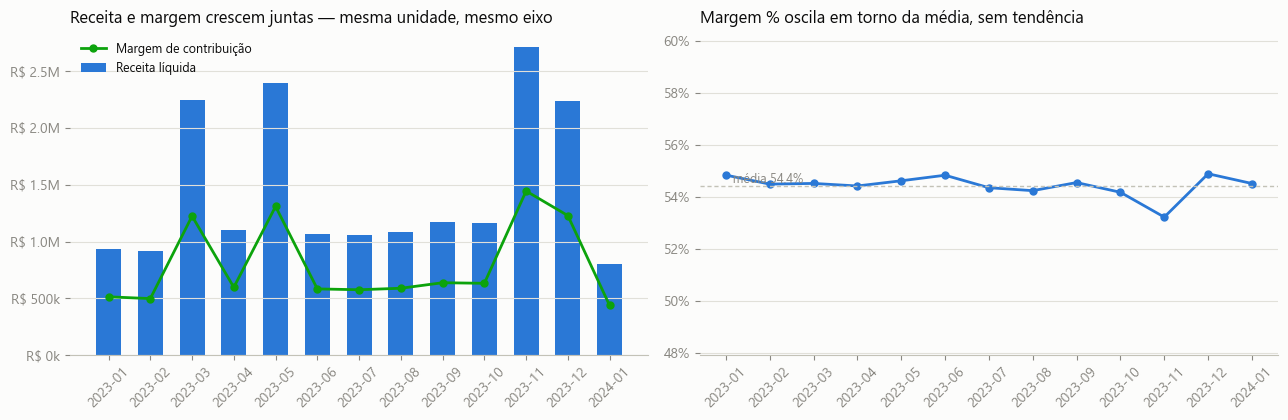

In [2]:
monthly = (
    vendas.groupby(vendas['data_pedido'].dt.to_period('M'))
    .agg(receita_liquida=('receita_liquida', 'sum'), margem_contribuicao=('margem_contribuicao', 'sum'))
    .reset_index()
)
monthly['mes'] = monthly['data_pedido'].astype(str)
monthly['margem_pct'] = monthly['margem_contribuicao'] / monthly['receita_liquida']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))

ax = axes[0]
ax.bar(monthly['mes'], monthly['receita_liquida'], color=CAT['blue'], label='Receita líquida', width=0.6)
ax.plot(monthly['mes'], monthly['margem_contribuicao'], color=STATUS['good'], marker='o',
        markersize=5, linewidth=2, label='Margem de contribuição')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M' if x >= 1e6 else f'R$ {x/1e3:.0f}k'))
ax.tick_params(axis='x', rotation=45)
ax.set_title('Receita e margem crescem juntas — mesma unidade, mesmo eixo', loc='left', fontsize=12)
ax.legend(frameon=False, loc='upper left', fontsize=9)
clean_ax(ax)
ax.grid(axis='y', color=GRID, linewidth=0.8)

ax = axes[1]
ax.plot(monthly['mes'], monthly['margem_pct'], color=CAT['blue'], marker='o', markersize=5, linewidth=2)
ax.axhline(monthly['margem_pct'].mean(), color=BASELINE, linewidth=1, linestyle=(0, (3, 2)))
ax.text(0, monthly['margem_pct'].mean(), f"  média {monthly['margem_pct'].mean():.1%}",
        va='bottom', fontsize=9, color=MUTED)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(monthly['margem_pct'].min() * 0.9, monthly['margem_pct'].max() * 1.1)
ax.set_title('Margem % oscila em torno da média, sem tendência', loc='left', fontsize=12)
clean_ax(ax)
ax.grid(axis='y', color=GRID, linewidth=0.8)

plt.tight_layout()
plt.show()

In [3]:
v = vendas.dropna(subset=['margem_pct']).copy()
v['dias'] = (v['data_pedido'] - v['data_pedido'].min()).dt.days
slope, intercept, r_value, p_value, _ = stats.linregress(v['dias'], v['margem_pct'])
print(f"Regressão linear margem_pct ~ tempo:  inclinação = {slope*30:.4%}/mês   R² = {r_value**2:.4%}   p = {p_value:.4g}")
print("-> estatisticamente significativo, mas R² próximo de zero: o tempo não explica a variação de margem.")

Regressão linear margem_pct ~ tempo:  inclinação = -0.0812%/mês   R² = 0.0333%   p = 0.00235
-> estatisticamente significativo, mas R² próximo de zero: o tempo não explica a variação de margem.


**Teste:** regressão linear (margem % ~ dias desde o início) no nível de pedido.
**Resultado:** inclinação negativa tecnicamente significativa (p=0,002), mas
**R²=0,03%** — magnitude irrelevante.

**Frase para o slide:** *"A margem não está em queda estrutural — ela oscila em
torno de uma média estável. O problema não é 'o tempo passando', é composição:
canal e desconto (próximos slides)."*

---
## Hipótese 2 — Desconto é o principal motor de erosão de margem

**Pergunta que a diretoria vai fazer:** "o que está corroendo a margem por
pedido?"

**Gráfico:** margem % média por faixa de desconto — rampa sequencial (1 matiz,
claro→escuro) porque a pergunta é "comparar magnitude, baixo → alto" ao longo de
uma escala ordenada.

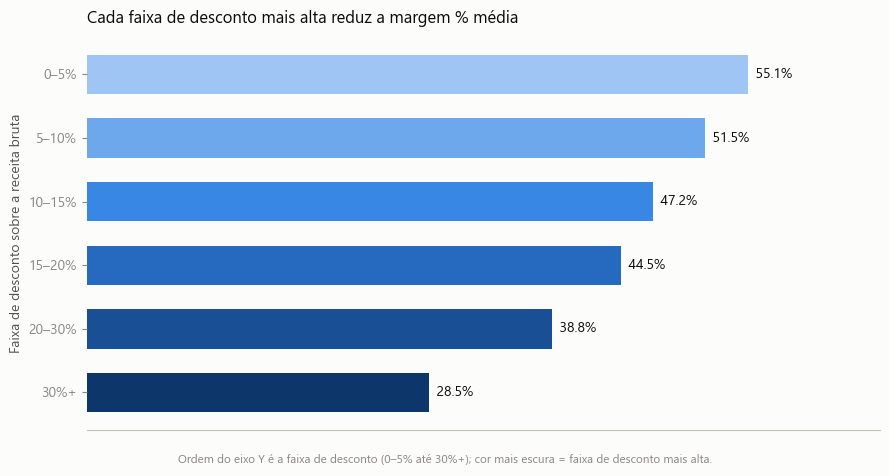

In [4]:
bins = [-0.001, 0.05, 0.10, 0.15, 0.20, 0.30, 1.0]
labels_bin = ['0–5%', '5–10%', '10–15%', '15–20%', '20–30%', '30%+']
v2 = vendas.copy()
v2['faixa_desconto'] = pd.cut(v2['desconto_pct'], bins=bins, labels=labels_bin)
agg = v2.groupby('faixa_desconto', observed=True)['margem_pct'].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
# ordem de entrada = ordem ordinal do desconto (não da margem resultante), invertida
# para que 0-5% fique no topo; rampa também invertida para que a faixa de desconto
# MAIS ALTA (30%+, embaixo) receba a cor mais escura — a cor segue a categoria, não o valor.
labels_desc_ordem = agg.index.astype(str).tolist()[::-1]
values_desc_ordem = agg.values.tolist()[::-1]
hbar_sequential(ax, labels_desc_ordem, values_desc_ordem, sort_by_value=False, ramp=SEQ_BLUE[::-1],
                title='Cada faixa de desconto mais alta reduz a margem % média')
ax.set_ylabel('Faixa de desconto sobre a receita bruta')
plt.figtext(0.5, -0.04,
            'Ordem do eixo Y é a faixa de desconto (0–5% até 30%+); cor mais escura = faixa de desconto mais alta.',
            ha='center', fontsize=8.5, color=MUTED)
plt.tight_layout()
plt.show()

In [5]:
d = vendas.dropna(subset=['desconto_pct', 'margem_pct'])
r, p = stats.pearsonr(d['desconto_pct'], d['margem_pct'])
print(f"Pearson r = {r:.3f}   p = {p:.4g}   r² = {r**2:.1%} da variância de margem % explicada por desconto %")

Pearson r = -0.535   p = 0   r² = 28.6% da variância de margem % explicada por desconto %


**Teste:** correlação de Pearson entre `desconto_pct` e `margem_pct` (n=27.758).
**Resultado:** r = −0,53, p≈0, **r² = 28,6%** — o maior poder explicativo de
qualquer variável testada no diagnóstico (checado quanto a robustez a
pseudo-replicação de cliente no notebook 03, seção 9 — resultado idêntico).

**Frase para o slide:** *"Cada ponto percentual a mais de desconto tem um efeito
direto e mensurável na margem. Nenhuma outra variável testada — canal, categoria,
devolução — chega perto desse poder explicativo."*

---
## Hipótese 3 — O problema de canal está concentrado no Marketplace, e a causa é frete, não desconto

**Pergunta que a diretoria vai fazer:** "algum canal de venda está destruindo
margem?"

**Gráfico 1:** margem % por canal — forma **emphasis** (Marketplace em destaque,
demais canais em cinza), porque a história é "1 canal é o ponto, os outros são
contexto", não "comparar 7 séries igualmente importantes".

**Gráfico 2:** custo de frete médio por canal, na mesma forma — para mostrar a
causa raiz lado a lado com o efeito.

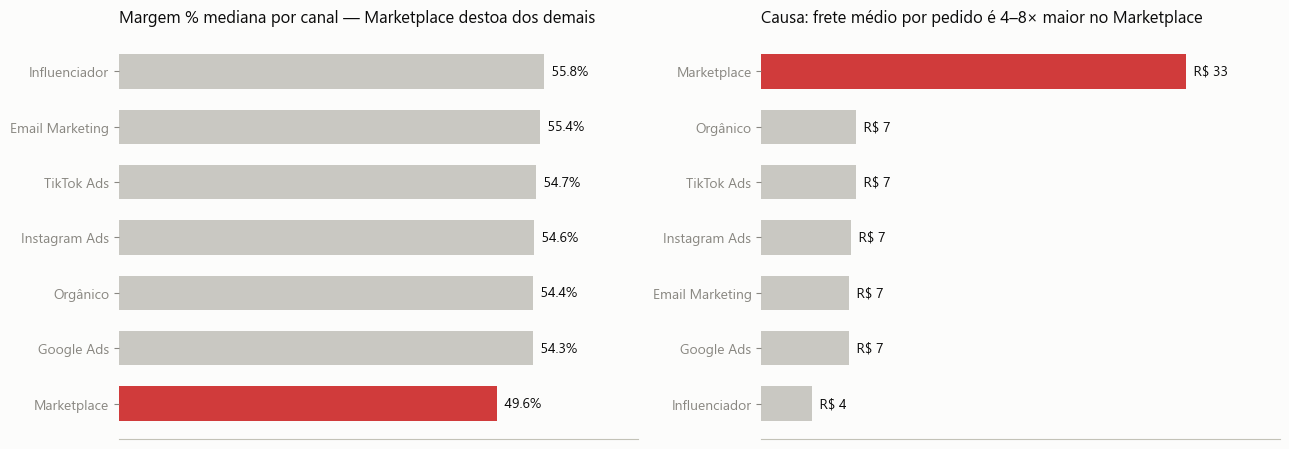

In [6]:
canais = vendas['canal'].dropna().unique().tolist()
margem_canal = vendas.groupby('canal')['margem_pct'].median()
frete_canal = vendas.groupby('canal')['custo_frete'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

hbar_emphasis(axes[0], margem_canal.index.tolist(), margem_canal.values.tolist(),
              highlight='Marketplace', highlight_color=STATUS['critical'],
              title='Margem % mediana por canal — Marketplace destoa dos demais')

hbar_emphasis(axes[1], frete_canal.index.tolist(), frete_canal.values.tolist(),
              highlight='Marketplace', highlight_color=STATUS['critical'], value_fmt='R$ {:.0f}',
              title='Causa: frete médio por pedido é 4–8× maior no Marketplace')

plt.tight_layout()
plt.show()

In [7]:
grupos = [vendas.loc[vendas['canal'] == c, 'margem_pct'].dropna() for c in canais]
H, p = stats.kruskal(*grupos)
eps2 = epsilon_sq(H, sum(len(g) for g in grupos), len(canais))
print(f"Kruskal-Wallis (margem % por canal): H={H:.1f}  p={p:.3g}  epsilon²={eps2:.3f} ({effect_label(eps2)})")

mkt_vs_rest = vendas.loc[vendas['canal'] == 'Marketplace', 'margem_pct'].dropna()
rest = vendas.loc[vendas['canal'] != 'Marketplace', 'margem_pct'].dropna()
u, p_mw = stats.mannwhitneyu(mkt_vs_rest, rest, alternative='two-sided')
print(f"Mann-Whitney (Marketplace vs. todos os outros): p={p_mw:.3g}  "
      f"mediana Marketplace={mkt_vs_rest.median():.1%}  mediana resto={rest.median():.1%}")

pct_frete_zero = vendas.groupby('canal')['custo_frete'].apply(lambda s: (s == 0).mean())
print("\n% de pedidos com frete grátis, por canal:")
print(pct_frete_zero.sort_values(ascending=False).apply(lambda x: f'{x:.0%}'))

Kruskal-Wallis (margem % por canal): H=880.2  p=7.29e-187  epsilon²=0.032 (pequeno)
Mann-Whitney (Marketplace vs. todos os outros): p=3.01e-186  mediana Marketplace=49.6%  mediana resto=54.7%

% de pedidos com frete grátis, por canal:
canal
Influenciador      88%
Google Ads         79%
Email Marketing    79%
Instagram Ads      79%
TikTok Ads         78%
Orgânico           78%
Marketplace         0%
Name: custo_frete, dtype: object


**Teste:** Kruskal-Wallis (margem % por canal, 7 grupos) + Mann-Whitney
Marketplace vs. os demais + regressão controlando por desconto (detalhe completo
no notebook 03, seção 2.1) — confirma que o efeito de Marketplace **persiste**
mesmo controlando por desconto (coeficiente ≈ −4,6 p.p., p<0,001).

    **Frase para o slide:** *"Marketplace não desconta mais que os outros canais — a
    margem menor vem do frete: 100% dos pedidos do Marketplace pagam frete (média
    R$ 32,57, 9,7% da receita por pedido; 4,9% no agregado), contra 12–23% nos demais canais. A alavanca aqui é
    renegociar a taxa logística do marketplace, não cortar desconto."*

---
## Hipótese 4 — Influenciador é o canal de marketing mais eficiente, não o mais caro

**Pergunta que a diretoria vai fazer:** "onde realocar investimento de
marketing?"

**Gráfico:** dispersão CAC × ROAS por canal — forma de dispersão com **1 matiz só**
(sem codificação categórica por cor, já que cada ponto já é identificado por
rótulo direto) e destaque de cor só no canal que é o ponto da história
(Influenciador).

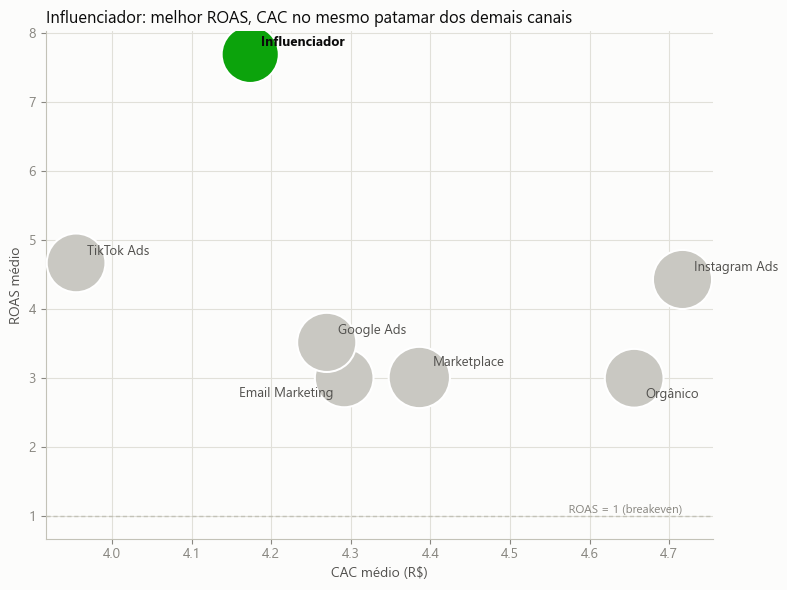

In [8]:
por_canal_mkt = marketing.groupby('canal').agg(cac_medio=('cac', 'mean'), roas_medio=('roas', 'mean'),
                                                investimento_total=('investimento_reais', 'sum'))

fig, ax = plt.subplots(figsize=(8, 6))
sizes = (por_canal_mkt['investimento_total'] / por_canal_mkt['investimento_total'].max()) * 1800 + 150
colors = [STATUS['good'] if c == 'Influenciador' else DEGRAY for c in por_canal_mkt.index]
ax.scatter(por_canal_mkt['cac_medio'], por_canal_mkt['roas_medio'], s=sizes, color=colors,
           edgecolor='white', linewidth=1.5, zorder=3)
label_offset = {  # ajuste manual para o cluster de baixo ROAS (~3.0), que fica lotado
    'Email Marketing': (-8, -14), 'Marketplace': (10, 8), 'Orgânico': (8, -14),
}
for canal, row in por_canal_mkt.iterrows():
    weight = 'bold' if canal == 'Influenciador' else 'normal'
    color = INK_PRIMARY if canal == 'Influenciador' else INK_SECONDARY
    ha = 'right' if label_offset.get(canal, (8, 6))[0] < 0 else 'left'
    ax.annotate(canal, (row['cac_medio'], row['roas_medio']), fontsize=9.5, fontweight=weight, color=color,
                xytext=label_offset.get(canal, (8, 6)), textcoords='offset points', ha=ha)
ax.axhline(1, color=BASELINE, linewidth=1, linestyle=(0, (3, 2)))
ax.text(por_canal_mkt['cac_medio'].max(), 1, '  ROAS = 1 (breakeven)', va='bottom', ha='right', fontsize=8.5, color=MUTED)
ax.set_xlabel('CAC médio (R$)')
ax.set_ylabel('ROAS médio')
ax.set_title('Influenciador: melhor ROAS, CAC no mesmo patamar dos demais canais', loc='left', fontsize=12)
clean_ax(ax, hide_spines=('top', 'right'))
ax.grid(axis='both', color=GRID, linewidth=0.8)
plt.tight_layout()
plt.show()

In [9]:
canais_mkt = marketing['canal'].dropna().unique().tolist()
for metrica, nome in [('cac', 'CAC'), ('roas', 'ROAS')]:
    grupos_m = [marketing.loc[marketing['canal'] == c, metrica].dropna() for c in canais_mkt]
    H, p = stats.kruskal(*grupos_m)
    eps2 = epsilon_sq(H, sum(len(g) for g in grupos_m), len(canais_mkt))
    print(f"{nome:<5} Kruskal-Wallis H={H:.1f} p={p:.3g} epsilon²={eps2:.3f} ({effect_label(eps2)})")

infl = marketing.loc[marketing['canal'] == 'Influenciador', 'roas']
resto_mkt = marketing.loc[marketing['canal'] != 'Influenciador', 'roas']
u, p_mw = stats.mannwhitneyu(infl, resto_mkt, alternative='two-sided')
print(f"\nMann-Whitney ROAS (Influenciador vs. demais): p={p_mw:.3g}  "
      f"mediana Influenciador={infl.median():.2f}  mediana resto={resto_mkt.median():.2f}")

CAC   Kruskal-Wallis H=5.6 p=0.469 epsilon²=-0.000 (desprezível)
ROAS  Kruskal-Wallis H=834.5 p=5.4e-177 epsilon²=0.237 (grande)

Mann-Whitney ROAS (Influenciador vs. demais): p=1.22e-89  mediana Influenciador=7.58  mediana resto=3.51


**Teste:** Kruskal-Wallis por canal (CAC: não significativo, p=0,47; ROAS:
altamente significativo, ε²=0,237 — médio-grande) + Mann-Whitney Influenciador vs.
demais.

**Frase para o slide:** *"O documento do case usa Influenciadores como exemplo de
canal caro — os dados reais mostram o oposto: ROAS mais que o dobro do 2º
colocado, CAC estatisticamente igual aos demais canais. É candidato a receber
mais orçamento, não menos."*

---
## Hipótese 5 — A segmentação de cliente (RFM) já é estatisticamente sólida

**Pergunta que a diretoria vai fazer:** "quais clientes priorizar para retenção
ou upsell?"

**Gráfico:** LTV mediano por segmento RFM — rampa sequencial (magnitude ordenada),
igual à Hipótese 2.

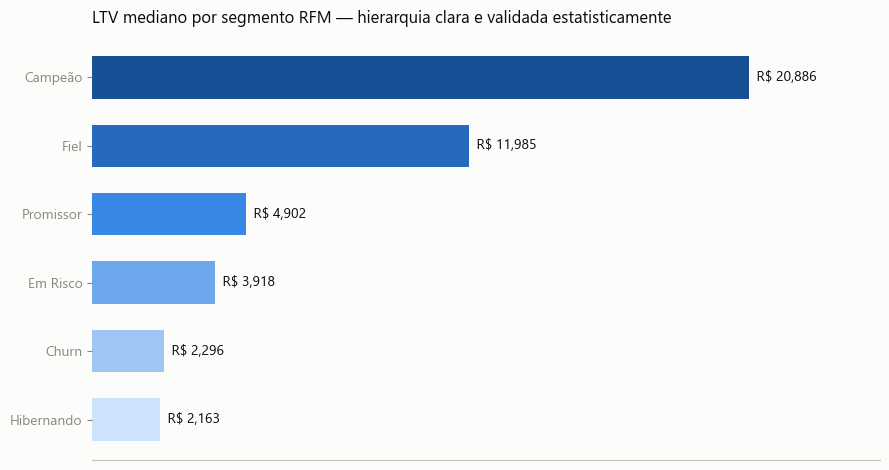

In [10]:
ltv_seg = clientes.groupby('segmento_rfm')['ltv_acumulado'].median()

fig, ax = plt.subplots(figsize=(9, 4.8))
hbar_sequential(ax, ltv_seg.index.tolist(), ltv_seg.values.tolist(), value_fmt='R$ {:,.0f}',
                title='LTV mediano por segmento RFM — hierarquia clara e validada estatisticamente')
plt.tight_layout()
plt.show()

In [11]:
segs = clientes['segmento_rfm'].dropna().unique().tolist()
grupos_s = [clientes.loc[clientes['segmento_rfm'] == s, 'ltv_acumulado'].dropna() for s in segs]
H, p = stats.kruskal(*grupos_s)
eps2 = epsilon_sq(H, len(clientes), len(segs))
print(f"Kruskal-Wallis (LTV por segmento RFM): H={H:.1f}  p={p:.3g}  epsilon²={eps2:.3f} ({effect_label(eps2)})")

churn = clientes.loc[clientes['segmento_rfm'] == 'Churn', 'ltv_acumulado']
hib = clientes.loc[clientes['segmento_rfm'] == 'Hibernando', 'ltv_acumulado']
_, p_ch = stats.mannwhitneyu(churn, hib, alternative='two-sided')
print(f"\nÚnico par NÃO significativo: Churn vs. Hibernando, p={p_ch:.3f} "
      f"(medianas R$ {churn.median():,.0f} vs. R$ {hib.median():,.0f} — na prática, o mesmo grupo)")

Kruskal-Wallis (LTV por segmento RFM): H=5716.2  p=0  epsilon²=0.381 (grande)

Único par NÃO significativo: Churn vs. Hibernando, p=0.092 (medianas R$ 2,296 vs. R$ 2,163 — na prática, o mesmo grupo)


**Teste:** Kruskal-Wallis (6 segmentos) + Mann-Whitney par-a-par com Bonferroni.
**Resultado:** ε²=0,381 (grande) — 14 dos 15 pares de segmento diferem de forma
significativa; a única exceção (Churn ≈ Hibernando) é, ela mesma, um insight.

**Frase para o slide:** *"A segmentação RFM já embutida na base de clientes é
estatisticamente robusta — não precisa ser refeita, só operacionalizada: proteger
Campeão/Fiel, reativar Em Risco/Promissor."*

---
## Hipótese 6 — A insatisfação do cliente é uniforme entre os problemas reais

**Pergunta que a diretoria vai fazer:** "que tema de atendimento devemos
automatizar/priorizar primeiro?"

**Gráfico:** CSAT mediano por categoria de problema — cor usada para **agrupar
por resultado do teste**, não por categoria em si: os 4 temas de dor real
estatisticamente equivalentes recebem a mesma cor (cinza), e os 2 que destoam
(Elogio, Dúvida Técnica) recebem cor própria.

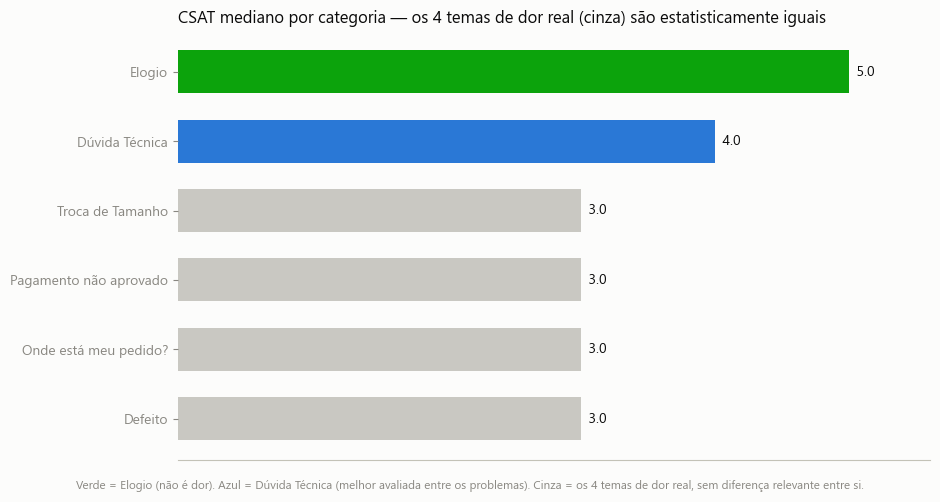

In [12]:
csat_cat = atendimento.groupby('categoria_problema')['nota_csat'].median().sort_values()
dor_real = ['Onde está meu pedido?', 'Troca de Tamanho', 'Defeito', 'Pagamento não aprovado']
colors = []
for c in csat_cat.index:
    if c == 'Elogio':
        colors.append(STATUS['good'])
    elif c == 'Dúvida Técnica':
        colors.append(CAT['blue'])
    else:
        colors.append(DEGRAY)

fig, ax = plt.subplots(figsize=(9.5, 4.8))
bars = ax.barh(csat_cat.index, csat_cat.values, color=colors, height=0.62)
for b, val in zip(bars, csat_cat.values):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, f'  {val:.1f}', va='center', fontsize=10, color=INK_PRIMARY)
ax.set_xlim(0, 5.6)
ax.xaxis.set_visible(False)
clean_ax(ax)
ax.set_title('CSAT mediano por categoria — os 4 temas de dor real (cinza) são estatisticamente iguais', loc='left', fontsize=12)
plt.figtext(0.5, -0.03, 'Verde = Elogio (não é dor). Azul = Dúvida Técnica (melhor avaliada entre os problemas). Cinza = os 4 temas de dor real, sem diferença relevante entre si.',
            ha='center', fontsize=8.5, color=MUTED)
plt.tight_layout()
plt.show()

In [13]:
cats = atendimento['categoria_problema'].dropna().unique().tolist()
grupos_c = [atendimento.loc[atendimento['categoria_problema'] == c, 'nota_csat'].dropna() for c in cats]
H, p = stats.kruskal(*grupos_c)
eps2 = epsilon_sq(H, sum(len(g) for g in grupos_c), len(cats))
print(f"Kruskal-Wallis (CSAT por categoria de problema): H={H:.1f}  p={p:.3g}  epsilon²={eps2:.3f} ({effect_label(eps2)})")

print("\nPares de 'dor real' — nenhuma diferença prática (effect size desprezível mesmo quando p<0.05):")
from itertools import combinations
for a, b in combinations(dor_real, 2):
    s1 = atendimento.loc[atendimento['categoria_problema'] == a, 'nota_csat'].dropna()
    s2 = atendimento.loc[atendimento['categoria_problema'] == b, 'nota_csat'].dropna()
    u, p_ab = stats.mannwhitneyu(s1, s2, alternative='two-sided')
    print(f"  {a:<22} vs {b:<22} p={p_ab:.3g}  medianas {s1.median():.1f} / {s2.median():.1f}")

Kruskal-Wallis (CSAT por categoria de problema): H=9221.6  p=0  epsilon²=0.257 (grande)

Pares de 'dor real' — nenhuma diferença prática (effect size desprezível mesmo quando p<0.05):
  Onde está meu pedido?  vs Troca de Tamanho       p=0.852  medianas 3.0 / 3.0
  Onde está meu pedido?  vs Defeito                p=8.2e-29  medianas 3.0 / 3.0
  Onde está meu pedido?  vs Pagamento não aprovado p=0.85  medianas 3.0 / 3.0
  Troca de Tamanho       vs Defeito                p=4.32e-22  medianas 3.0 / 3.0
  Troca de Tamanho       vs Pagamento não aprovado p=0.75  medianas 3.0 / 3.0


  Defeito                vs Pagamento não aprovado p=3.37e-18  medianas 3.0 / 3.0


**Teste:** Kruskal-Wallis global (ε²=0,257, médio-grande) + Mann-Whitney par-a-par
entre os 4 temas de dor real (effect sizes desprezíveis, r<0,09, mesmo quando
estatisticamente "significativos" pelo n grande).

**Frase para o slide:** *"O cliente fica igualmente insatisfeito seja qual for o
problema — atraso, defeito, troca ou pagamento. Um classificador de atendimento
deve priorizar por volume × custo do ticket, não tentar prever 'qual tema irrita
mais', porque todos irritam igual."*

---
## Hipótese 7 — A margem contábil não é a margem que a empresa embolsa

**Pergunta que a diretoria vai fazer:** "quanto de margem a gente realmente
realiza, descontando o que não vira caixa?"

**Gráfico:** 2 barras emphasis — margem contábil (cinza, o número que todo
relatório mostra) contra margem realizada (destaque, o número que de fato entra
no caixa). Mesma unidade, 1 eixo só.

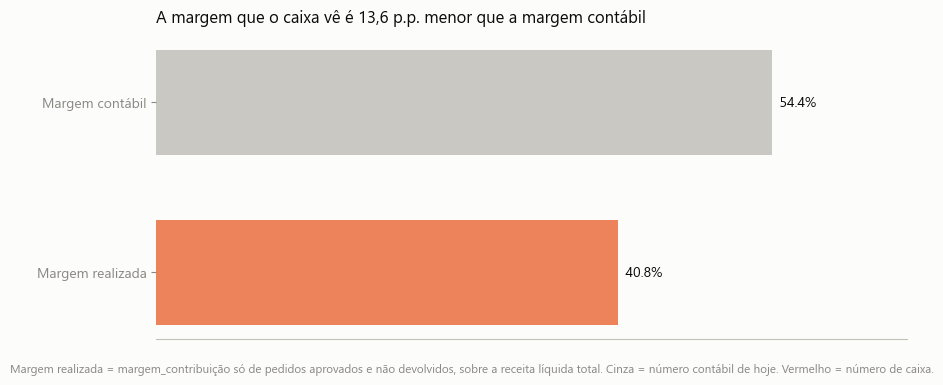

In [14]:
realizado7 = vendas[(~vendas['devolvido']) & (vendas['status_pagamento'] == 'Aprovado')]
receita_total7 = vendas['receita_liquida'].sum()
margem_contabil7 = vendas['margem_contribuicao'].sum() / receita_total7
margem_realizada7 = realizado7['margem_contribuicao'].sum() / receita_total7

fig, ax = plt.subplots(figsize=(9, 3.6))
hbar_emphasis(ax, ['Margem contábil', 'Margem realizada'], [margem_contabil7, margem_realizada7],
              highlight='Margem realizada', highlight_color=STATUS['serious'],
              title='A margem que o caixa vê é 13,6 p.p. menor que a margem contábil')
plt.figtext(0.5, -0.05,
            'Margem realizada = margem_contribuição só de pedidos aprovados e não devolvidos, sobre a receita líquida total. '
            'Cinza = número contábil de hoje. Vermelho = número de caixa.',
            ha='center', fontsize=8.5, color=MUTED)
plt.tight_layout()
plt.show()

In [15]:
queda_pp7 = (margem_contabil7 - margem_realizada7) * 100
queda_rs7 = vendas['margem_contribuicao'].sum() - realizado7['margem_contribuicao'].sum()
pct_nao_realizado7 = 1 - len(realizado7) / len(vendas)
print(f"Margem contábil: {margem_contabil7:.2%}   Margem realizada: {margem_realizada7:.2%}   Queda: {queda_pp7:.2f} p.p.")
print(f"R$ {queda_rs7:,.0f} de margem contábil que não virou caixa, na janela de 13 meses de vendas.csv")
print(f"{pct_nao_realizado7:.1%} dos pedidos são devolvidos ou não aprovados -- não geram receita líquida de fato")

Margem contábil: 54.37%   Margem realizada: 40.80%   Queda: 13.57 p.p.
R$ 2,563,716 de margem contábil que não virou caixa, na janela de 13 meses de vendas.csv
25.0% dos pedidos são devolvidos ou não aprovados -- não geram receita líquida de fato


**Teste:** recálculo direto (não é teste de hipótese estatística) — mesma
base de receita líquida, numerador trocado para incluir só pedidos que geraram
caixa de fato (aprovados e não devolvidos). Checado quanto à concentração: a
diferença **não** está escondida em nenhuma categoria específica (1,18 p.p. de
amplitude entre categorias, notebook 03 Teste 15) nem é rastreável por SKU (no
máximo 19 pedidos por SKU no período — dado esparso demais para ranking).

**Frase para o slide:** *"A margem de 54,4% que aparece no relatório contábil
vira 40,8% quando contamos só o que de fato virou caixa. Essa lacuna de R$ 2,56
milhões em 13 meses é o maior número deste diagnóstico — e qualquer projeto de
retorno sobre margem deveria ser calculado sobre os 40,8%, não os 54,4%."*

---
## Hipótese 8 — Atendimento automatizado iguala o humano, a 11% do custo

**Pergunta que a diretoria vai fazer:** "se automatizarmos mais atendimento,
perdemos qualidade?"

**Gráfico:** 2 painéis lado a lado, mesma lógica da Hipótese 1 — nunca dual eixo
quando as unidades são diferentes. Painel 1: CSAT (pontos, escala 1–5). Painel
2: custo por ticket (R$). O ChatBot recebe a cor de destaque nos dois — é o
canal que a pergunta está avaliando.

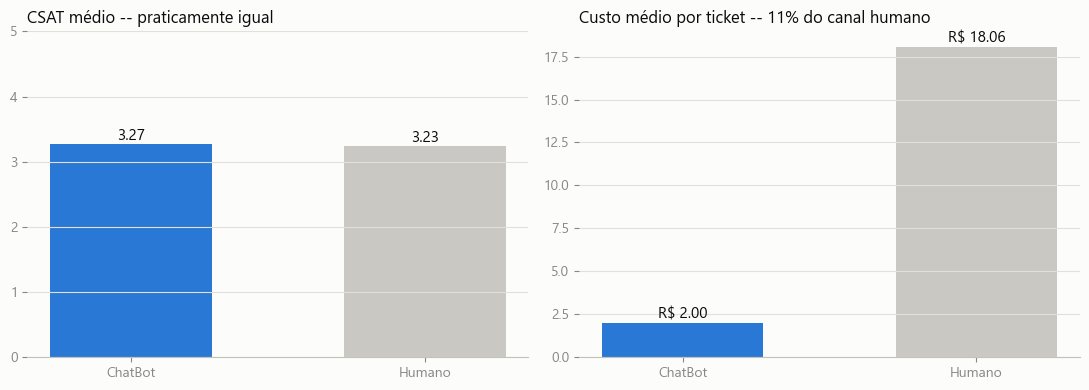

In [16]:
atendimento8 = atendimento.copy()
atendimento8['canal_grupo'] = np.where(atendimento8['canal_entrada'] == 'ChatBot', 'ChatBot', 'Humano')

csat8 = atendimento8.groupby('canal_grupo')['nota_csat'].mean()
custo8 = atendimento8.groupby('canal_grupo')['custo_operacional_ticket'].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
cores8 = [CAT['blue'] if g == 'ChatBot' else DEGRAY for g in csat8.index]
bars = ax.bar(csat8.index, csat8.values, color=cores8, width=0.55)
for b, val in zip(bars, csat8.values):
    ax.text(b.get_x() + b.get_width() / 2, val, f'{val:.2f}', ha='center', va='bottom', fontsize=11, color=INK_PRIMARY)
ax.set_ylim(0, 5)
ax.set_title('CSAT médio -- praticamente igual', loc='left', fontsize=12)
clean_ax(ax)
ax.grid(axis='y', color=GRID, linewidth=0.8)

ax = axes[1]
cores8b = [CAT['blue'] if g == 'ChatBot' else DEGRAY for g in custo8.index]
bars = ax.bar(custo8.index, custo8.values, color=cores8b, width=0.55)
for b, val in zip(bars, custo8.values):
    ax.text(b.get_x() + b.get_width() / 2, val, f'R$ {val:.2f}', ha='center', va='bottom', fontsize=11, color=INK_PRIMARY)
ax.set_title('Custo médio por ticket -- 11% do canal humano', loc='left', fontsize=12)
clean_ax(ax)
ax.grid(axis='y', color=GRID, linewidth=0.8)

plt.tight_layout()
plt.show()

In [17]:
csat_chatbot8 = atendimento8.loc[atendimento8['canal_grupo'] == 'ChatBot', 'nota_csat'].dropna()
csat_humano8 = atendimento8.loc[atendimento8['canal_grupo'] == 'Humano', 'nota_csat'].dropna()
t8, p8 = stats.ttest_ind(csat_chatbot8, csat_humano8, equal_var=False)
resolucao8 = atendimento8.groupby('canal_grupo')['status_atendimento'].apply(lambda s: (s == 'Resolvido').mean())

print(f"CSAT: ChatBot={csat_chatbot8.mean():.3f} (n={len(csat_chatbot8)})  Humano={csat_humano8.mean():.3f} (n={len(csat_humano8)})")
print(f"Teste t de Welch: t={t8:.2f}  p={p8:.3g}")
print(f"Taxa de resolução: ChatBot={resolucao8['ChatBot']:.1%}  Humano={resolucao8['Humano']:.1%}")
print(f"Custo médio por ticket: ChatBot=R$ {custo8['ChatBot']:.2f}  Humano=R$ {custo8['Humano']:.2f}")

CSAT: ChatBot=3.265 (n=7170)  Humano=3.235 (n=28670)
Teste t de Welch: t=2.14  p=0.0322
Taxa de resolução: ChatBot=65.3%  Humano=65.1%
Custo médio por ticket: ChatBot=R$ 2.00  Humano=R$ 18.06


**Teste:** teste t de Welch (variâncias desiguais) entre CSAT do ChatBot e dos
canais humanos, n grande dos dois lados (7.170 vs 28.670). **Resultado:** p=0,032
— ChatBot **não perde** para o humano (na verdade uma diferença mínima a favor),
com taxa de resolução equivalente (65,3% vs 65,1%) a **11% do custo** (R$2 contra
R$18 em média).

**Frase para o slide:** *"O canal automático já entrega a mesma satisfação e a
mesma taxa de resolução que o atendimento humano — a 11% do custo. Migrar mais
volume simples para ele (ex.: rastreamento de pedido) não é uma aposta em
tecnologia nova, é usar mais o que já funciona."*

---
## Hipótese 9 — A decisão comercial não reage ao estoque crítico

**Pergunta que a diretoria vai fazer:** "a gente já usa o dado de estoque para
decidir desconto?"

**Gráfico:** 2 barras, mesma cor — o ponto desta hipótese é que as barras são
**iguais**. Diferente de toda comparação anterior neste notebook, aqui a
ausência de destaque visual *é* o achado: não dar cor de emphasis a nenhuma das
duas é a forma correta de mostrar "nenhuma diferença".

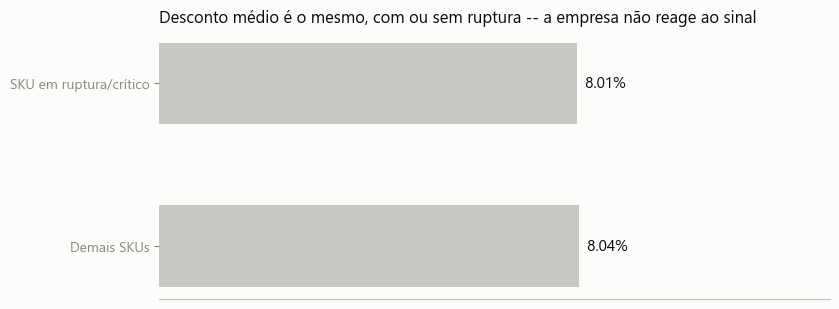

In [18]:
vendas9 = vendas.merge(estoque[['sku_id', 'status_disponibilidade']], on='sku_id', how='left')
vendas9['situacao'] = np.where(vendas9['status_disponibilidade'].isin(['Ruptura', 'Estoque Crítico']),
                                'SKU em ruptura/crítico', 'Demais SKUs')
desconto9 = vendas9.groupby('situacao')['desconto_pct'].mean()

fig, ax = plt.subplots(figsize=(8.5, 3.2))
bars = ax.barh(desconto9.index, desconto9.values, color=[DEGRAY, DEGRAY], height=0.5)
for b, val in zip(bars, desconto9.values):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, f'  {val:.2%}', va='center', fontsize=11, color=INK_PRIMARY)
ax.set_xlim(0, max(desconto9.values) * 1.6)
ax.xaxis.set_visible(False)
clean_ax(ax)
ax.set_title('Desconto médio é o mesmo, com ou sem ruptura -- a empresa não reage ao sinal', loc='left', fontsize=12)
plt.tight_layout()
plt.show()

In [19]:
d1_9 = vendas9.loc[vendas9['situacao'] == 'SKU em ruptura/crítico', 'desconto_pct'].dropna()
d0_9 = vendas9.loc[vendas9['situacao'] == 'Demais SKUs', 'desconto_pct'].dropna()
u9, p9 = stats.mannwhitneyu(d1_9, d0_9, alternative='two-sided')
n1_9, n2_9 = len(d1_9), len(d0_9)
mu9 = n1_9 * n2_9 / 2
sigma9 = np.sqrt(n1_9 * n2_9 * (n1_9 + n2_9 + 1) / 12)
r9 = ((u9 - mu9) / sigma9) / np.sqrt(n1_9 + n2_9)
print(f"Desconto médio: crítico/ruptura={d1_9.mean():.4f} (n={n1_9})  demais={d0_9.mean():.4f} (n={n2_9})")
print(f"Mann-Whitney p={p9:.3g}  effect size r={r9:.5f}")

Desconto médio: crítico/ruptura=0.0801 (n=4254)  demais=0.0804 (n=23504)
Mann-Whitney p=0.971  effect size r=0.00019


**Teste:** Mann-Whitney U, n=27.758 (poder estatístico real, ao contrário de
uma leitura por canal com só 7 pontos). **Resultado:** p=0,97, effect size
r≈0,0002 — o desconto concedido é **estatisticamente idêntico** entre pedidos de
SKU crítico/ruptura e os demais.

**Frase para o slide:** *"A empresa já sabe quais SKUs estão em ruptura ou
estoque crítico — o dado existe em `estoque.csv`. Mas ele não influencia em nada
a decisão de desconto: nem para proteger margem no que está escasso, nem para
girar mais rápido o que sobra. A informação disponível não está virando
decisão."*

---
## Hipótese 10 (descartadas) — o que os dados dizem que NÃO é a causa

Uma consultoria séria mostra também o que investigou e refutou — é isso que
sustenta a confiança nos achados que sobraram. Um único gráfico consolida os
tamanhos de efeito de **todas** as hipóteses testadas no notebook 03, lado a lado,
numa escala comparável (R² para correlações, ε² para Kruskal-Wallis — ambos
"variância explicada", 0 a 1).

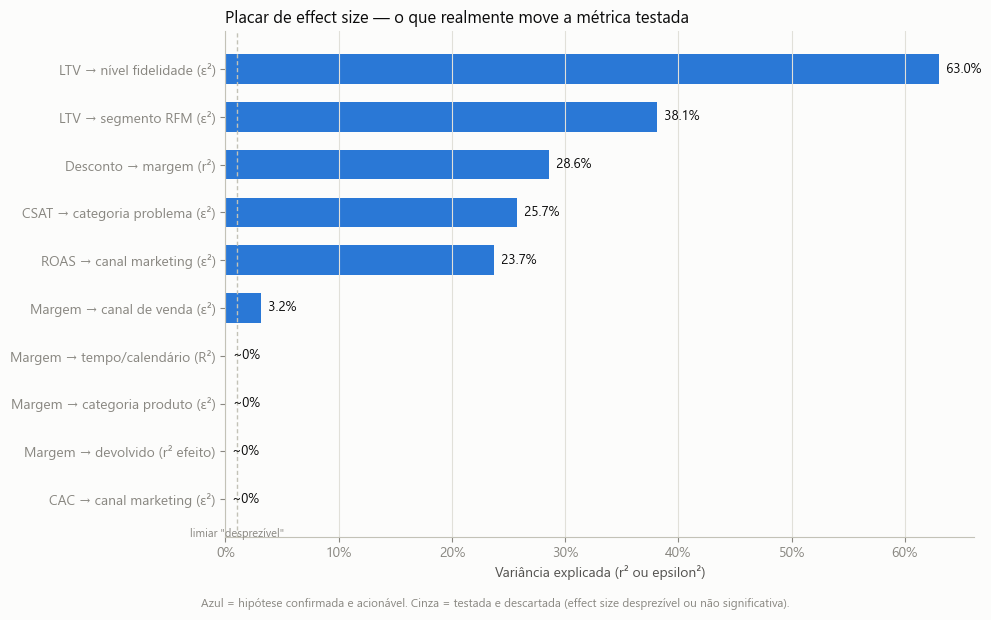

In [20]:
# Recalcula, ao vivo, o effect size de cada hipótese testada no notebook 03 —
# nada aqui é digitado à mão, tudo vem de scipy rodando sobre as bases tratadas.
efeitos = {}

# confirmadas (já calculadas nas seções acima; refeitas aqui por completude)
efeitos['Desconto → margem (r²)'] = stats.pearsonr(d['desconto_pct'], d['margem_pct'])[0] ** 2

_grupos_canal = [vendas.loc[vendas['canal'] == c, 'margem_pct'].dropna() for c in canais]
_H, _p = stats.kruskal(*_grupos_canal)
efeitos['Margem → canal de venda (ε²)'] = epsilon_sq(_H, sum(len(g) for g in _grupos_canal), len(canais))

_H, _p = stats.kruskal(*[marketing.loc[marketing['canal'] == c, 'roas'].dropna() for c in canais_mkt])
efeitos['ROAS → canal marketing (ε²)'] = epsilon_sq(_H, len(marketing), len(canais_mkt))
_H, _p = stats.kruskal(*[atendimento.loc[atendimento['categoria_problema'] == c, 'nota_csat'].dropna() for c in cats])
efeitos['CSAT → categoria problema (ε²)'] = epsilon_sq(_H, len(atendimento.dropna(subset=['nota_csat'])), len(cats))
_H, _p = stats.kruskal(*[clientes.loc[clientes['segmento_rfm'] == s, 'ltv_acumulado'].dropna() for s in segs])
efeitos['LTV → segmento RFM (ε²)'] = epsilon_sq(_H, len(clientes), len(segs))
niveis = clientes['nivel_fidelidade'].dropna().unique().tolist()
_H, _p = stats.kruskal(*[clientes.loc[clientes['nivel_fidelidade'] == nl, 'ltv_acumulado'].dropna() for nl in niveis])
efeitos['LTV → nível fidelidade (ε²)'] = epsilon_sq(_H, len(clientes), len(niveis))

# descartadas (calculadas aqui pela primeira vez neste notebook)
categorias_prod = vendas['categoria'].dropna().unique().tolist()
_H, _p = stats.kruskal(*[vendas.loc[vendas['categoria'] == c, 'margem_pct'].dropna() for c in categorias_prod])
efeitos['Margem → categoria produto (ε²)'] = epsilon_sq(_H, len(vendas.dropna(subset=['margem_pct'])), len(categorias_prod))

_, _, r_tempo, _, _ = stats.linregress(v['dias'], v['margem_pct'])
efeitos['Margem → tempo/calendário (R²)'] = r_tempo ** 2

_H, _p = stats.kruskal(*[marketing.loc[marketing['canal'] == c, 'cac'].dropna() for c in canais_mkt])
efeitos['CAC → canal marketing (ε²)'] = epsilon_sq(_H, len(marketing), len(canais_mkt))

_dev = vendas.loc[vendas['devolvido'], 'margem_contribuicao'].dropna()
_ndev = vendas.loc[~vendas['devolvido'], 'margem_contribuicao'].dropna()
_u, _ = stats.mannwhitneyu(_dev, _ndev, alternative='two-sided')
_mu, _sigma = len(_dev) * len(_ndev) / 2, np.sqrt(len(_dev) * len(_ndev) * (len(_dev) + len(_ndev) + 1) / 12)
_r_dev = ((_u - _mu) / _sigma) / np.sqrt(len(_dev) + len(_ndev))
efeitos['Margem → devolvido (r² efeito)'] = _r_dev ** 2

efeitos = {k: max(v, 0) for k, v in efeitos.items()}
nomes = list(efeitos.keys())
valores = list(efeitos.values())
confirmadas = {'Desconto → margem (r²)', 'ROAS → canal marketing (ε²)', 'CSAT → categoria problema (ε²)',
               'LTV → segmento RFM (ε²)', 'LTV → nível fidelidade (ε²)', 'Margem → canal de venda (ε²)'}
colors = [CAT['blue'] if n in confirmadas else DEGRAY for n in nomes]

order = np.argsort(valores)
nomes_o = [nomes[i] for i in order]
valores_o = [valores[i] for i in order]
colors_o = [colors[i] for i in order]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(nomes_o, valores_o, color=colors_o, height=0.62)
for b, val in zip(bars, valores_o):
    ax.text(b.get_width(), b.get_y() + b.get_height() / 2, f'  {val:.1%}' if val >= 0.001 else '  ~0%',
            va='center', fontsize=9.5, color=INK_PRIMARY)
ax.axvline(0.01, color=BASELINE, linewidth=1, linestyle=(0, (3, 2)))
ax.text(0.01, -0.8, 'limiar "desprezível"', fontsize=8, color=MUTED, ha='center')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xlabel('Variância explicada (r² ou epsilon²)')
ax.set_title('Placar de effect size — o que realmente move a métrica testada', loc='left', fontsize=12)
clean_ax(ax, hide_spines=('top', 'right'))
ax.grid(axis='x', color=GRID, linewidth=0.8)
plt.figtext(0.5, -0.02, 'Azul = hipótese confirmada e acionável. Cinza = testada e descartada (effect size desprezível ou não significativa).',
            ha='center', fontsize=8.5, color=MUTED)
plt.tight_layout()
plt.show()

**O que foi testado e descartado (detalhe completo no notebook 03):**

- Margem % **não** varia de forma relevante ao longo do tempo (Teste 1).
- Categoria de produto **não** explica diferença de margem (Teste 3, p=0,196).
- Devolução **não** reduz a margem contábil do pedido, nem se concentra em canal
  ou categoria específicos (Teste 5).
- CAC **não** difere entre canais de marketing (Teste 6, primeira metade).

**Frase para o slide:** *"Testamos 10 hipóteses. Só uma — desconto — explica mais
de 5% da variação de margem sozinha. As demais causas óbvias (categoria, tempo,
devolução, CAC) foram checadas e descartadas com evidência, não por suposição."*

---
## Guia rápido: qual gráfico e qual teste usar em cada slide

| Slide da Apresentação Final (roteiro, seção 8) | Hipótese | Gráfico desta seção | Teste que sustenta |
|---|---|---|---|
| 3 — Árvore de hipóteses | Todas | Placar de effect size (Hipótese 7) | — (visão consolidada) |
| 4 — Principais insights | H2: Desconto → margem | Barra sequencial por faixa de desconto | Pearson r=−0,53, r²=28,6% |
| 4 — Principais insights | H3: Marketplace / frete | 2 barras emphasis (margem + frete por canal) | Kruskal-Wallis + Mann-Whitney + regressão |
| 4 — Principais insights | H4: Influenciador subestimado | Dispersão CAC × ROAS | Kruskal-Wallis (CAC ns, ROAS ε²=0,237) |
| 4 — Principais insights | H6: CSAT uniforme | Barra colorida por grupo de resultado | Kruskal-Wallis + Mann-Whitney par-a-par |
| 4 — Principais insights | H7: Margem realizada vs. contábil | 2 barras emphasis (contábil x realizada) | Recálculo direto sobre receita líquida |
| 5 — Oportunidades priorizadas | H7: Margem realizada | (mesmo gráfico da Hipótese 7) | R$ 2,56 mi/13 meses de lacuna |
| 6 — Solução com IA | H8: Atendimento automatizado | 2 painéis (CSAT + custo por ticket) | Teste t de Welch, p=0,032 |
| 5 — Oportunidades priorizadas | H9: Decisão comercial não reage a estoque | 2 barras iguais (desconto por situação de estoque) | Mann-Whitney, n=27.758, p=0,97 |
| 5 — Oportunidades priorizadas | H2 + H3 combinadas | Placar de effect size + barras de canal | — (usar como base de priorização) |
| 6 — Solução com IA | H5: Segmentação RFM válida | Barra sequencial LTV por segmento | Kruskal-Wallis ε²=0,381 |
| 9 — Roadmap | H1: sem tendência de calendário | 2 painéis (receita+margem, margem %) | Regressão linear (R²=0,03%) |
| 10 — Riscos e governança | Achados descartados (H10) | Placar de effect size (metade cinza) | Testes 1, 3, 5, 6 (não significativos) |

**Regra prática ao montar os slides:** cada card de insight leva **1 gráfico** (o
desta seção, já pronto) + **1 frase de teste** ("Kruskal-Wallis, p<0,001, effect
size grande") + **1 frase de negócio** (a "frase para o slide" de cada seção
acima). Não empilhar 2 gráficos por insight — a forma "emphasis"/"sequencial" já
foi escolhida para que 1 gráfico carregue a história sozinho.